### getting started

#### libraries and path to XATOM

In [1]:
import subprocess
import re

import os
import shutil
from datetime import datetime

import sys
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.cm as cm
from matplotlib.colors import TwoSlopeNorm

from itertools import cycle

import pandas as pd

import json

import ast

from collections import defaultdict

XATOMPATH = '/Users/parkinpham/Programming/xraypac/xatom/src'

from scipy.integrate import solve_ivp

#### fundamental constants

In [2]:
import scipy.constants as const

# Constants
hbar_J_s = const.hbar  # Reduced Planck's constant (Joule seconds)

e_charge = const.e
fs = 1e-15
hbar_eV_fs = hbar_J_s / (e_charge * fs)

E_Hartree_eV = const.physical_constants['Hartree energy in eV'][0]

a_u_time_in_fs = hbar_eV_fs / E_Hartree_eV
print(f'a_u_time_in_fs = {a_u_time_in_fs:.4f} fs')

a_u_rate_in_fsm1 = 1 / a_u_time_in_fs
print(f'a_u_rate_in_fsm1 = {a_u_rate_in_fsm1:.4f} fs^-1')

a_u_rate_in_eV = hbar_eV_fs * a_u_rate_in_fsm1
print(f'a_u_rate_in_eV = {a_u_rate_in_eV:.2f} eV')

a_u_time_in_fs = 0.0242 fs
a_u_rate_in_fsm1 = 41.3414 fs^-1
a_u_rate_in_eV = 27.21 eV


In [3]:
nm = 1e-9
bohr_radius_meters = const.physical_constants["Bohr radius"][0]

a_u_length_in_nm = bohr_radius_meters / nm
print(f'a_u_length_in_nm = {a_u_length_in_nm:.4f} nm')

a_u_area_in_nm2 = a_u_length_in_nm**2
print(f'a_u_area_in_nm2 = {a_u_area_in_nm2:.4f} nm2')

a_u_length_in_nm = 0.0529 nm
a_u_area_in_nm2 = 0.0028 nm2


In [4]:
nm2_in_kbarn = nm**2 / (1e3 * 1e-28)

print(f'nm2_in_kbarn = {nm2_in_kbarn:.1e}')

nm2_in_kbarn = 1.0e+07


#### input parameters

In [5]:
beam_area = 180 * 220 #nm2

energy_Ka1 = 8244.76 # eV, to agree with the transition energy calculated by XATOM

print(f'energy_Ka1 = {energy_Ka1} eV')
print(f'beam_area = {beam_area/1e6:.4f} um^2')

energy_Ka1 = 8244.76 eV
beam_area = 0.0396 um^2


In [6]:
# Define the Gaussian pulse for I(t)
t0 = 12  # Center of the pulse (12 fs)
FWHM = 6   # Full width at half maximum (6 fs)
sigma = FWHM / (2 * np.sqrt(2 * np.log(2)))

def I_pump(t):
    return (1 / np.sqrt(2 * np.pi * sigma**2)) * np.exp(-(t - t0)**2 / (2 * sigma**2))

In [7]:
E_pump_J = 40e-6
print(f'E_pump_J = {E_pump_J:.2e}')

hw_photon = 8020 #eV, to keep photon number to be 3.11e10 for 40 uJ
N_pump_phot = E_pump_J / (hw_photon * const.e)
print(f'N_pump_phot = {N_pump_phot:.2e}')

pump_fluence = N_pump_phot / beam_area
print(f'pump fluence = {E_pump_J / beam_area *1e14:.2e} J/cm2')
print(f'pump_fluence = {pump_fluence:.2e} ph/nm2')

E_pump_J = 4.00e-05
N_pump_phot = 3.11e+10
pump fluence = 1.01e+05 J/cm2
pump_fluence = 7.86e+05 ph/nm2


## XATOM relativistic

### run a Monte-Carlo dynamics with XATOM to get the relevant configurations

#### running XATOM

In [8]:
def run_xatom_mc_fly(PE, FWHM, N_photons, spatial_area, relativity_mode='-relativity'):
    # Construct the command with all the required parameters
    command = (
        f'{XATOMPATH}/xatom_mc_fly -s Cu -relativity -PE {PE} -pathway -FWHM {FWHM} -N_photons {N_photons} -spatial_area {spatial_area} -track_res -track_cs'
    )
    
    # Execute the command and stream the output in real-time
    process = subprocess.Popen(command, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    
    # Read the output line by line
    for line in process.stdout:
        print(line, end="")  # Print to Jupyter Notebook on the fly
    
    # Wait for the process to complete and capture any errors
    stderr = process.communicate()[1]
    if stderr:
        print(f"Error:\n{stderr}")

# run_xatom_mc_fly(energy_Ka1, FWHM, N_pump_phot, beam_area/1e6)

In [9]:
def copy_and_rename_track_cs(XATOMPATH, PE, FWHM, N_photons, spatial_area):
    # Construct the source file path
    source_file = os.path.join(XATOMPATH, 'track_cs')
    
    # Check if the source file exists
    if not os.path.exists(source_file):
        print(f"Error: File '{source_file}' does not exist.")
        return
    
    # Get the current timestamp
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Construct the new filename with parameters and timestamp
    new_filename = f'track_cs_{timestamp}_PE{PE}_FWHM{FWHM}_Nphotons{N_photons:.2E}_Area{spatial_area:.4f}.dat'
    
    # Copy the file to the current directory with the new name
    destination_file = os.path.join(os.getcwd(), new_filename)
    shutil.copy2(source_file, destination_file)
    
    print(f"File copied and renamed to '{new_filename}'")


# After running the xatom_mc_fly function
# copy_and_rename_track_cs(XATOMPATH, energy_Ka1, FWHM, N_pump_phot, beam_area/1e6)


#### getting all configurations

In [10]:
track_cs_filename = 'track_cs_20240809_150337_PE8244.76_FWHM6_Nphotons3.11E+10_Area0.0396.dat'

def parse_xatom_track_file(track_cs_filename):
    configurations_visited = set(['1s2_2s2_2p2,4_3s2_3p2,4_4s2_3d4,5'])
    total_trajectories = 0
    current_trajectory = []

    with open(track_cs_filename, 'r') as file:
        for line in file:
            line = line.strip()
            if line:
                # Non-blank line, part of a trajectory
                parts = line.split()
                configuration = parts[3]
                configurations_visited.add(configuration)
                current_trajectory.append(line)
            else:
                # Blank line, indicating a possible end of a trajectory
                if current_trajectory:
                    total_trajectories += 1
                    current_trajectory = []

        # Check if the last trajectory ended without a trailing blank line
        if current_trajectory:
            total_trajectories += 1

    return total_trajectories, sorted(configurations_visited, reverse = True)

# Example usage
total_trajectories, visited_configurations = parse_xatom_track_file(track_cs_filename)

print(f"Total number of trajectories: {total_trajectories}")
print(f"\nTotal number of  visited configurations: {len(visited_configurations)}")
# print("\nList of visited configurations:")
# for config in visited_configurations:
#     print(config)

Total number of trajectories: 8185

Total number of  visited configurations: 1340


### transitions matrices

#### calculate and export transitions dictionary

In [12]:
command = f'{XATOMPATH}/xatom -s Cu -conf {visited_configurations[0]} -relativity -pcs -PE {energy_Ka1} -decay -xmdyn -silent'

print(command)

# Run the subprocess to execute XATOM with the given configuration
sp = subprocess.run(command, shell=True,
                    stdout=subprocess.PIPE,
                    stderr=subprocess.PIPE,
                    stdin=subprocess.PIPE)

print(sp.stdout.decode('utf8'))

/Users/parkinpham/Programming/xraypac/xatom/src/xatom -s Cu -conf 1s2_2s2_2p2,4_3s2_3p2,4_4s2_3d4,5 -relativity -pcs -PE 8244.76 -decay -xmdyn -silent


  -1680.73452837
  1  0    -8969.47    10987.67    0.053
  2  0    -1098.71     2084.68    0.237
  2  1     -972.19     2080.43    0.206
  2  1     -951.59     2101.03    0.206
  3  0     -128.92      464.78    0.711
  3  1      -88.07      421.12    0.736
  3  1      -85.43      423.76    0.736
  4  0       -8.46       37.43    2.755
  3  2      -16.64      298.30    0.885
  3  2      -16.30      298.64    0.885
dat         9
 P                   546750                   546747   8.2629609137129881E-005       7146 #   2  2  2  4  2  2  4  2  4  5 ->   2  1  2  4  2  2  4  2  4  5
 P                   546750                   546741   2.2690909129205313E-005       7273 #   2  2  2  4  2  2  4  2  4  5 ->   2  2  1  4  2  2  4  2  4  5
 P                   546750                   546723   4.4888753125218772E-005       7293 #   2  2  2  4  2  2  4  2  4  5 ->   2  2  2  3  2  2  4  2  4  5
 P                   546750                   546615   1.1883386251622525E-005       8116 #   2  2

In [13]:
def process_configurations_with_progress(config_list, pump_photon_energy):
    transitions_dict_relativistic = {}
    total_configs = len(config_list)

    for i, c in enumerate(config_list):
        # Print progress
        progress = (i + 1) / total_configs * 100
        sys.stdout.write(f"\rProcessing configuration: {c} ({i + 1}/{total_configs}), Progress: {progress:.2f}% completed.")
        sys.stdout.flush()
        
        command = f'{XATOMPATH}/xatom -s Cu -conf {c} -relativity -pcs -PE {pump_photon_energy} -decay -xmdyn -silent'

        print(command)

        # Run the subprocess to execute XATOM with the given configuration
        sp = subprocess.run(command, shell=True,
                            stdout=subprocess.PIPE,
                            stderr=subprocess.PIPE,
                            stdin=subprocess.PIPE)

        # Initialize an empty list to store the results for the current configuration
        transitions_dict_relativistic[c] = []

        print(sp.stdout.decode('utf8'))

        # Process the output from the subprocess
        for line in sp.stdout.decode('utf8').split('\n'):
            print(line)
            if '#' in line:
                parts = line.split()
                transition_part = ' '.join(parts[6:])
                initial_config, final_config = transition_part.split(' -> ')
                result_entry = {
                    'type': parts[0],  # P, F, A, V, etc.
                    'initial_state': parts[1],
                    'final_state': parts[2],
                    'rate': float(parts[3]),
                    'transition_energy': float(parts[4]),
                    'initial_config': initial_config.strip(),
                    'final_config': final_config.strip()
                }
                transitions_dict_relativistic[c].append(result_entry)
        

    print("\nProcessing complete.")
    return transitions_dict_relativistic

transitions_dict_relativistic = process_configurations_with_progress(visited_configurations, energy_Ka1)

Processing configuration: 1s2_2s2_2p2,4_3s2_3p2,4_4s2_3d4,5 (1/1340), Progress: 0.07% completed./Users/parkinpham/Programming/xraypac/xatom/src/xatom -s Cu -conf 1s2_2s2_2p2,4_3s2_3p2,4_4s2_3d4,5 -relativity -pcs -PE 8244.76 -decay -xmdyn -silent


KeyboardInterrupt: 

In [ ]:
def save_transitions_dict_to_json(transitions_dict, filename):
    # Convert numpy arrays to lists for JSON serialization
    serializable_dict = {}
    for key, value in transitions_dict.items():
        serializable_dict[key] = []
        for item in value:
            item_copy = item.copy()
            item_copy['rate'] = float(item_copy['rate'])  # Ensure rates are serializable as float
            serializable_dict[key].append(item_copy)

    # Save to JSON file
    with open(filename, 'w') as f:
        json.dump(serializable_dict, f, indent=4)


# save_transitions_dict_to_json(transitions_dict_relativistic, 'transitions_dict_relativistic.json')


#### import transitions dictionary

In [ ]:
with open('transitions_dict_relativistic.json', 'r') as f:
        serializable_dict = json.load(f)
    
# Convert lists back to numpy arrays if needed
transitions_dict_relativistic = {}
for key, value in serializable_dict.items():
    transitions_dict_relativistic[key] = []
    for item in value:
        item_copy = item.copy()
        item_copy['rate'] = float(item_copy['rate'])  # Ensure rates are floats
        transitions_dict_relativistic[key].append(item_copy)

#### getting the matrix

In [ ]:
process_types = set()

# Iterate over each configuration in the dictionary
for config, transitions in transitions_dict_relativistic.items():
    # Iterate over each transition in the list of transitions
    for transition in transitions:
        # Add the process type to the set
        process_types.add(transition['type'])

# Convert the set to a sorted list
process_types_list = sorted(list(process_types))

process_types_list

['A', 'F', 'P', 'V']

In [ ]:
def convert_reltivistic_configuration_string(config_string):
    # Define the subshells corresponding to the array indices
    subshells = ['1s', '2s', '2p', '3s', '3p', '4s', '3d']

    # Split the input string into individual numbers
    config_list = config_string.split()

    # Generate the configuration string
    result = []
    index = 0
    for subshell in subshells:
        if subshell.endswith('p') or subshell.endswith('d'):  
            # For p and d orbitals, we consider two numbers from the config_list
            occupancy_low = config_list[index]
            occupancy_high = config_list[index + 1]
            result.append(f"{subshell}{occupancy_low},{occupancy_high}")
            index += 2  # Move to the next orbital
        else:
            # For s orbitals, we consider one number from the config_list
            occupancy = config_list[index]
            result.append(f"{subshell}{occupancy}")
            index += 1  # Move to the next orbital

    # Join the parts with underscores
    formatted_config = '_'.join(result)

    return formatted_config

# Example usage
config_string = '2 2 2 4 2 2 4 2 4 5'
formatted_configuration = convert_reltivistic_configuration_string(config_string)
print(formatted_configuration)

1s2_2s2_2p2,4_3s2_3p2,4_4s2_3d4,5


In [ ]:
# Initialize the transition matrix
N = len(visited_configurations)
transition_matrix = np.zeros((N, N))

# Initialize the transition matrices for each process type
transition_matrices = {ptype: np.zeros((len(visited_configurations), len(visited_configurations))) for ptype in process_types_list}

# Populate the transition matrices
for initial_config, transitions in transitions_dict_relativistic.items():
    initial_index = visited_configurations.index(initial_config)
    for transition in transitions:
        final_config = convert_reltivistic_configuration_string(transition['final_config'])
        rate = transition['rate']
        process_type = transition['type']

        if final_config in visited_configurations:
            final_index = visited_configurations.index(final_config)
        else:
            final_index = -1

        # Depopulation of the initial state
        transition_matrices[process_type][initial_index, initial_index] -= rate
        if final_index != -1:
            # Population of the final state if it exists in the list
            transition_matrices[process_type][final_index, initial_index] += rate

#### plotting matrix

In [ ]:
# %matplotlib widget

# for process_type in process_types_list:

#     transition_matrix = np.array(transition_matrices[process_type])

#     fig, ax = plt.subplots(figsize=(12, 12))

#     # Define the colormap normalization
#     norm = TwoSlopeNorm(vmin=transition_matrix.min(), vcenter=0, vmax=transition_matrix.max())

#     # Display the matrix with imshow
#     cax = ax.imshow(transition_matrix, cmap='seismic', norm=norm)

#     # Add a colorbar with split colors
#     cbar = fig.colorbar(cax, orientation='vertical', fraction=0.046, pad=0.04)
#     cbar.set_label('Transition Rate')

#     # Set the tick labels
#     ax.set_xticks(np.arange(len(visited_configurations)))
#     ax.set_yticks(np.arange(len(visited_configurations)))
#     ax.set_xticklabels(visited_configurations, rotation=90, fontsize=10)
#     ax.set_yticklabels(visited_configurations, fontsize=10)

#     # Add axis labels
#     ax.set_xlabel('Initial Configuration')
#     ax.set_ylabel('Final Configuration')

#     # Title for the plot
#     plt.title(f'Transition Matrix {process_type} Visualization')

#     # Display the plot
#     plt.tight_layout()
#     # plt.grid(True)
#     plt.show()

#### converting units

In [ ]:
rate_A_fsm1_ij = transition_matrices['A'] * a_u_rate_in_fsm1

rate_F_fsm1_ij = transition_matrices['F'] * a_u_rate_in_fsm1

rate_AF_fsm1_ij = rate_A_fsm1_ij + rate_F_fsm1_ij

rate_PV_nm2_ij = (transition_matrices['P'] + transition_matrices['V']) * a_u_area_in_nm2

### rate equations

#### initial condition

In [ ]:
initial_configuration = '1s2_2s2_2p2,4_3s2_3p2,4_4s2_3d4,5'

# Find the position of the target configuration in the list
position_initial_configuration = visited_configurations.index(initial_configuration)

# Create a vector of zeros with the same length as the list of configurations
initial_population_i = np.zeros(len(visited_configurations))

# Set the element at the found position to 1
initial_population_i[position_initial_configuration] = 1

print(f"Position of '{initial_configuration}' in visited_configurations: {position_initial_configuration}")
print(f"Resulting initial_population_i: {initial_population_i}")

Position of '1s2_2s2_2p2,4_3s2_3p2,4_4s2_3d4,5' in visited_configurations: 0
Resulting initial_population_i: [1. 0. 0. ... 0. 0. 0.]


#### pump temporal profile and fluence

In [ ]:
t_grid_calc = np.linspace(0, 24, 2401)

J_pump_t_calc = pump_fluence * I_pump(t_grid_calc)
print(f'total energy = {np.trapz(J_pump_t_calc, x = t_grid_calc) * beam_area * hw_photon * const.e:.2e} J')

J_pump_t_max = J_pump_t_calc[int(len(t_grid_calc)/2)]
print(f'peak flux = {J_pump_t_max:.2e} ph/nm*2/fs')

total energy = 4.00e-05 J
peak flux = 1.23e+05 ph/nm*2/fs


#### dp / dt

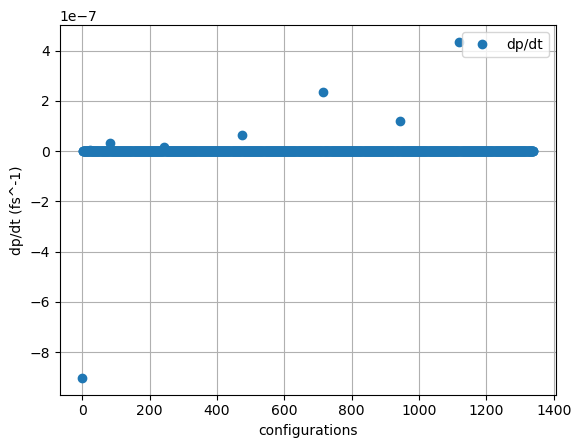

In [ ]:
# Function to compute dp/dt
def rate_equation(t, p):
    rate_matrix = rate_AF_fsm1_ij + pump_fluence * I_pump(t) * rate_PV_nm2_ij
    dpdt = rate_matrix @ p
    return dpdt

plt.figure()
plt.plot(rate_equation(0, initial_population_i), 'o', label = 'dp/dt')
plt.grid(True)
plt.xlabel('configurations')
plt.ylabel('dp/dt (fs^-1)')
plt.legend()
plt.show()

#### integration

In [ ]:
# Define the time span for the integration
t_span = (t_grid_calc[0], t_grid_calc[-1]) 
t_eval = np.linspace(*t_span, 241)  # Points at which to store the solution

# Solve the ODE system
solution = solve_ivp(rate_equation, t_span, initial_population_i, t_eval=t_eval, method='RK45')

# Extract the solution
xatom_relativistic_t   = np.asarray(solution.t)
xatom_relativistic_populations_i_t = np.asarray(solution.y)

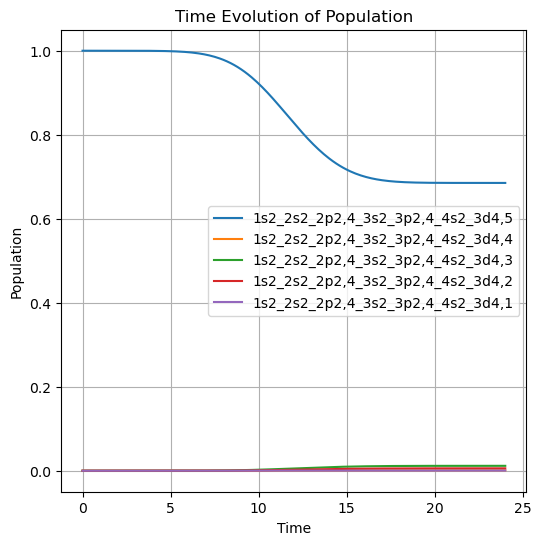

In [ ]:
plt.figure(figsize=(6, 6))
for i in range(5):  # Plotting the first 5 components as an example
    plt.plot(xatom_relativistic_t, xatom_relativistic_populations_i_t[i,:], label=f'{visited_configurations[i]}')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Time Evolution of Population')
plt.legend()
plt.grid(True)
plt.show()

### select states relevant for Kalpha_1,2 fluorescence 

#### functions for changing configurations

In [ ]:
def extract_2p_electrons(config_string):
    # Split the string by underscores to get individual subshell configurations
    subshells = config_string.split('_')
    
    # Initialize variables for 2p- and 2p+ electron counts
    electrons_2p_minus = 0
    electrons_2p_plus = 0
    
    # Loop through each subshell
    for subshell in subshells:
        # Check if the subshell starts with "2p"
        if subshell.startswith('2p'):
            # Split the subshell string by commas to separate the counts
            parts = subshell[2:].split(',')
            if len(parts) == 2:
                electrons_2p_minus = int(parts[0])
                electrons_2p_plus = int(parts[1])
            break  # No need to check further once 2p is found
    
    return electrons_2p_minus, electrons_2p_plus


In [ ]:
def modify_configuration_for_1s_2p_transition(config_string, increase_2p_minus=False, increase_2p_plus=False):
    # Split the string by underscores to get individual subshell configurations
    subshells = config_string.split('_')
    
    # Initialize variables to hold the modified configuration parts
    new_subshells = []

    for subshell in subshells:
        if subshell.startswith('1s'):
            num_1s_electrons = int(subshell[2:])
            
            # Decrease the number of 1s electrons by 1
            if increase_2p_minus or increase_2p_plus:      
                if num_1s_electrons > 0:
                    num_1s_electrons -= 1
                    
            new_subshells.append(f'1s{num_1s_electrons}')
            
        elif subshell.startswith('2p'):
            # Split the subshell string by commas to separate the counts
            parts = subshell[2:].split(',')
            electrons_2p_minus = int(parts[0])
            electrons_2p_plus = int(parts[1])

            # Increase either 2p- or 2p+ by 1 based on the input
            if increase_2p_minus:
                if electrons_2p_minus < 2:
                    electrons_2p_minus += 1
                
            if increase_2p_plus:
                if electrons_2p_plus < 4:
                    electrons_2p_plus += 1

            new_subshells.append(f'2p{electrons_2p_minus},{electrons_2p_plus}')
        else:
            # Leave other subshells unchanged
            new_subshells.append(subshell)

    # Join the modified subshells back into a configuration string
    new_config_string = '_'.join(new_subshells)
    
    return new_config_string

modify_configuration_for_1s_2p_transition('1s2_2s2_2p2,3_3s2_3p2,2_4s2_3d4,5', increase_2p_minus=False, increase_2p_plus=True)

'1s1_2s2_2p2,4_3s2_3p2,2_4s2_3d4,5'

#### pre-selecting configurations

length of visited_2p_hole_configurations: 459


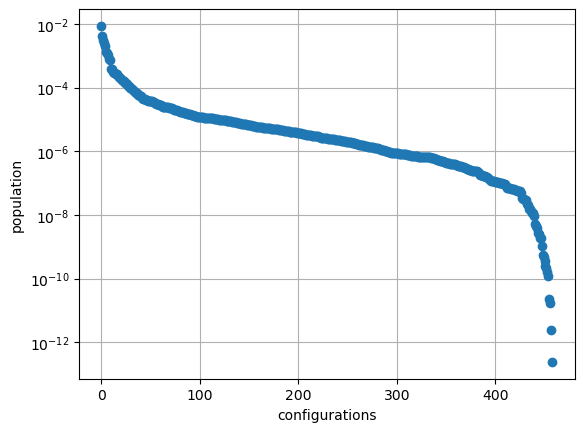

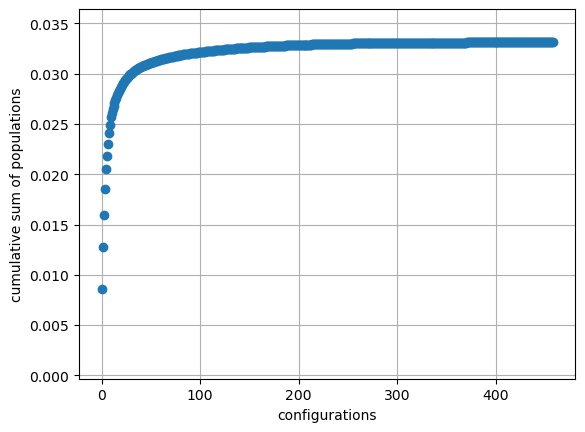

In [ ]:
# Create a boolean mask indicating which configurations have 2p holes
visited_2p_hole_configurations_mask = [sum(extract_2p_electrons(conf)) < 6 for conf in visited_configurations]

# Use list comprehension to filter configurations with 2p holes
visited_2p_hole_configurations = [conf for conf, has_hole in zip(visited_configurations, visited_2p_hole_configurations_mask) if has_hole]

print(f'length of visited_2p_hole_configurations: {len(visited_2p_hole_configurations)}')

# Calculate the integral values for sorting
populations_2p_hole_i_t = xatom_relativistic_populations_i_t[visited_2p_hole_configurations_mask]
integral_values_2p_hole = [np.trapz(I_pump(xatom_relativistic_t) * population, xatom_relativistic_t) for population in populations_2p_hole_i_t]

# Combine configurations, populations, and integral values into a list of tuples
combined = list(zip(visited_2p_hole_configurations, populations_2p_hole_i_t, integral_values_2p_hole))

# Sort the combined list by integral values
combined.sort(key=lambda x: x[2], reverse=True)

# Unzip the sorted list back into separate lists
visited_2p_hole_configurations_sorted, populations_2p_hole_i_t_sorted, integral_values_2p_hole_sorted = zip(*combined)

plt.figure()
plt.plot(integral_values_2p_hole_sorted, 'o')
plt.grid(True)
plt.xlabel('configurations')
plt.ylabel('population')
plt.yscale('log')
plt.show()


cumulative_sum = np.cumsum(integral_values_2p_hole_sorted)
plt.figure()
plt.plot(cumulative_sum, 'o')
plt.grid(True)
plt.xlabel('configurations')
plt.ylabel('cumulative sum of populations')
plt.ylim(-0.01*cumulative_sum[-1], 1.1 * cumulative_sum[-1])
plt.show()

length of visited_Ka1_configurations: 292
visited_Ka1_configurations_thresholded: 
1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,5
1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,4
1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d3,5
1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d3,4
1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,3
1s2_2s2_2p2,3_3s2_3p2,3_4s2_3d4,5



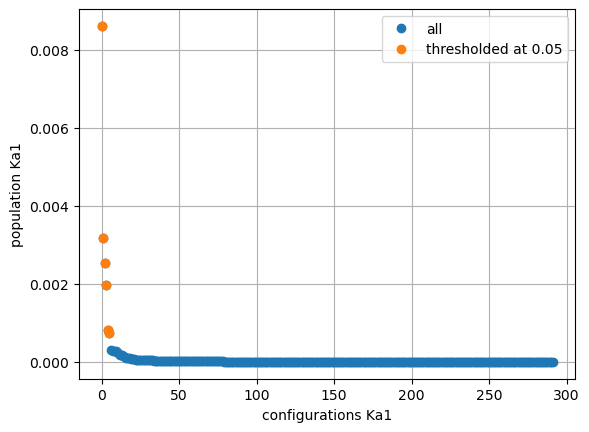

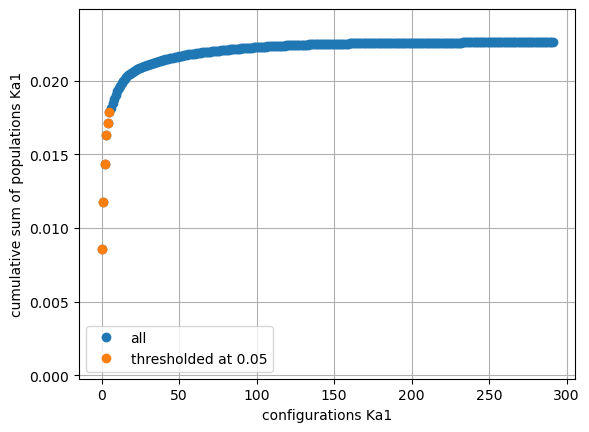

In [ ]:
# Create a boolean mask indicating which configurations have 2p holes
visited_Ka1_configurations_mask = [extract_2p_electrons(conf)[1] < 4 for conf in visited_configurations]

# Use list comprehension to filter configurations with 2p holes
visited_Ka1_configurations = [conf for conf, has_hole in zip(visited_configurations, visited_Ka1_configurations_mask) if has_hole]

print(f'length of visited_Ka1_configurations: {len(visited_Ka1_configurations)}')

# Calculate the integral values for sorting
populations_Ka1_i_t = xatom_relativistic_populations_i_t[visited_Ka1_configurations_mask]
integral_values_Ka1 = [np.trapz(I_pump(xatom_relativistic_t) * population, xatom_relativistic_t) for population in populations_Ka1_i_t]

# Combine configurations, populations, and integral values into a list of tuples
combined = list(zip(visited_Ka1_configurations, populations_Ka1_i_t, integral_values_Ka1))

# Sort the combined list by integral values
combined.sort(key=lambda x: x[2], reverse=True)

# Unzip the sorted list back into separate lists
visited_Ka1_configurations_sorted, populations_Ka1_i_t_sorted, integral_values_Ka1_sorted = zip(*combined)

threshold_Ka1 = 0.05

threshold_mask_Ka1 = np.asarray(integral_values_Ka1_sorted) > threshold_Ka1 * integral_values_Ka1_sorted[0]
visited_Ka1_configurations_thresholded = [conf for conf, mask in zip(visited_Ka1_configurations_sorted, threshold_mask_Ka1) if mask]
integral_values_Ka1_sorted_thresholded = np.asarray(integral_values_Ka1_sorted)[threshold_mask_Ka1]

conf_for_label = ''
for conf in visited_Ka1_configurations_thresholded:
    conf_for_label = conf_for_label + f'{conf}\n'
print(f'visited_Ka1_configurations_thresholded: \n{conf_for_label}')


plt.figure()
plt.plot(integral_values_Ka1_sorted, 'o', label = 'all')
plt.plot(np.asarray(integral_values_Ka1_sorted)[threshold_mask_Ka1], 'o', label = f'thresholded at {threshold_Ka1}')
plt.grid(True)
plt.xlabel('configurations Ka1')
plt.ylabel('population Ka1')
# plt.yscale('log')
plt.legend()
plt.show()


cumulative_sum_Ka1 = np.asarray(np.cumsum(integral_values_Ka1_sorted))
plt.figure()
plt.plot(cumulative_sum_Ka1, 'o', label = 'all')
plt.plot(cumulative_sum_Ka1[threshold_mask_Ka1], 'o', label = f'thresholded at {threshold_Ka1}')
plt.grid(True)
plt.xlabel('configurations Ka1')
plt.ylabel('cumulative sum of populations Ka1')
plt.ylim(-0.01*cumulative_sum_Ka1[-1], 1.1 * cumulative_sum_Ka1[-1])
plt.legend()
plt.show()

length of visited_Ka2_configurations: 192
visited_Ka2_configurations_thresholded: 
1s2_2s2_2p1,4_3s2_3p2,4_4s2_3d4,5
1s2_2s2_2p1,4_3s2_3p2,4_4s2_3d4,4
1s2_2s2_2p1,4_3s2_3p2,4_4s2_3d3,4
1s2_2s2_2p1,4_3s2_3p2,4_4s2_3d3,5
1s2_2s2_2p1,4_3s2_3p2,3_4s2_3d4,5
1s2_2s2_2p1,4_3s2_3p2,4_4s2_3d4,3



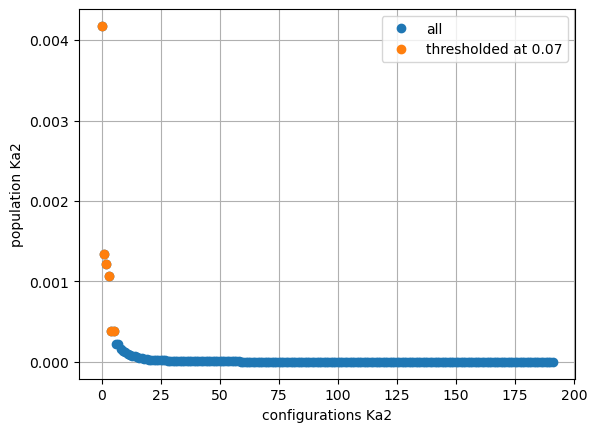

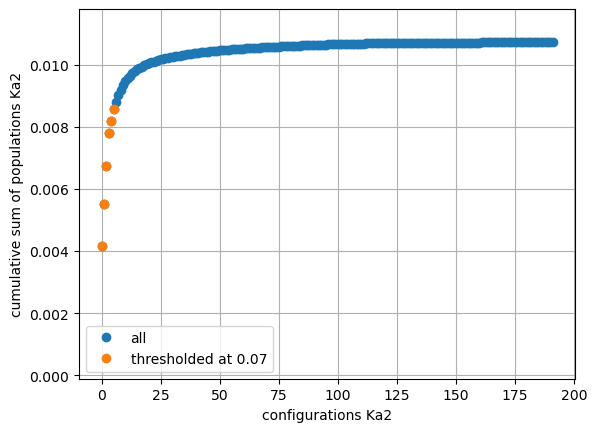

In [ ]:
# Create a boolean mask indicating which configurations have 2p holes
visited_Ka2_configurations_mask = [extract_2p_electrons(conf)[0] < 2 for conf in visited_configurations]

# Use list comprehension to filter configurations with 2p holes
visited_Ka2_configurations = [conf for conf, has_hole in zip(visited_configurations, visited_Ka2_configurations_mask) if has_hole]

print(f'length of visited_Ka2_configurations: {len(visited_Ka2_configurations)}')

# Calculate the integral values for sorting
populations_Ka2_i_t = xatom_relativistic_populations_i_t[visited_Ka2_configurations_mask]
integral_values_Ka2 = [np.trapz(I_pump(xatom_relativistic_t) * population, xatom_relativistic_t) for population in populations_Ka2_i_t]

# Combine configurations, populations, and integral values into a list of tuples
combined = list(zip(visited_Ka2_configurations, populations_Ka2_i_t, integral_values_Ka2))

# Sort the combined list by integral values
combined.sort(key=lambda x: x[2], reverse=True)

# Unzip the sorted list back into separate lists
visited_Ka2_configurations_sorted, populations_Ka2_i_t_sorted, integral_values_Ka2_sorted = zip(*combined)

threshold_Ka2 = 0.07

threshold_mask_Ka2 = np.asarray(integral_values_Ka2_sorted) > threshold_Ka2 * integral_values_Ka2_sorted[0]
visited_Ka2_configurations_thresholded = [conf for conf, mask in zip(visited_Ka2_configurations_sorted, threshold_mask_Ka2) if mask]
integral_values_Ka2_sorted_thresholded = np.asarray(integral_values_Ka2_sorted)[threshold_mask_Ka2]

conf_for_label = ''
for conf in visited_Ka2_configurations_thresholded:
    conf_for_label = conf_for_label + f'{conf}\n'
print(f'visited_Ka2_configurations_thresholded: \n{conf_for_label}')


plt.figure()
plt.plot(integral_values_Ka2_sorted, 'o', label = 'all')
plt.plot(np.asarray(integral_values_Ka2_sorted)[threshold_mask_Ka2], 'o', label = f'thresholded at {threshold_Ka2}')
plt.grid(True)
plt.xlabel('configurations Ka2')
plt.ylabel('population Ka2')
# plt.yscale('log')
plt.legend()
plt.show()


cumulative_sum_Ka2 = np.asarray(np.cumsum(integral_values_Ka2_sorted))
plt.figure()
plt.plot(cumulative_sum_Ka2, 'o', label = 'all')
plt.plot(cumulative_sum_Ka2[threshold_mask_Ka2], 'o', label = f'thresholded at {threshold_Ka2}')
plt.grid(True)
plt.xlabel('configurations Ka2')
plt.ylabel('cumulative sum of populations Ka2')
plt.ylim(-0.01*cumulative_sum_Ka2[-1], 1.1 * cumulative_sum_Ka2[-1])
plt.legend()
plt.show()

#### single fluorescence line calculation

In [ ]:
def run_xatom_decay(config):
    command = f'{XATOMPATH}/xatom -s Cu -config {config} -relativity -decay'
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    return result.stdout

def parse_decay_output(output):
    rates = {
        "1s0-2p-_energy": None,
        "1s0-2p+_energy": None,
        "1s0-2p-_rate": None,
        "1s0-2p+_rate": None,
        "total_F_rate": None,
        "total_A_rate": None,
        "total_decay_rate": None
    }
    
    # 1s0 - 2p- energy and rate
    match = re.search(r'1s0\s+-\s+2p-\s+:\s+([0-9.]+)\s+([0-9.]+E[+-][0-9]+)', output)
    if match:
        rates["1s0-2p-_energy"] = float(match.group(1))
        rates["1s0-2p-_rate"] = float(match.group(2))
        
    # 1s0 - 2p+ energy and rate
    match = re.search(r'1s0\s+-\s+2p\+\s+:\s+([0-9.]+)\s+([0-9.]+E[+-][0-9]+)', output)
    if match:
        rates["1s0-2p+_energy"] = float(match.group(1))
        rates["1s0-2p+_rate"] = float(match.group(2))

    # Total F rate
    match = re.search(r'Total F rate\s+=\s+([0-9.]+E[+-][0-9]+)\s+a.u.', output)
    if match:
        rates["total_F_rate"] = float(match.group(1))

    # Total A rate
    match = re.search(r'Total A rate\s+=\s+([0-9.]+E[+-][0-9]+)', output)
    if match:
        rates["total_A_rate"] = float(match.group(1))
        
    # Total decay rate
    match = re.search(r'Total decay rate\s+=\s+([0-9.]+E[+-][0-9]+)', output)
    if match:
        rates["total_decay_rate"] = float(match.group(1))
    
    return rates


def f_line_properties_possible_for_config(config):
    
    electrons_2p_minus, electrons_2p_plus = extract_2p_electrons(config)
    
    is_transition_Ka2 = electrons_2p_minus < 2
    is_transition_Ka1 = electrons_2p_plus < 4
    
    f_line_property = {}
    
    if is_transition_Ka1 or is_transition_Ka2:
        decay_output_2p = run_xatom_decay(config)
        rates_2p = parse_decay_output(decay_output_2p)
        f_line_property['width_2p_eV'] = rates_2p['total_decay_rate'] * a_u_rate_in_eV
        
    if is_transition_Ka1:
        config_transition_Ka1 = modify_configuration_for_1s_2p_transition(config, increase_2p_minus=False, increase_2p_plus=True)
        
        decay_output_1s_Ka1 = run_xatom_decay(config_transition_Ka1)
        rates_1s_Ka1 = parse_decay_output(decay_output_1s_Ka1)
        f_line_property['energy_Ka1_eV'] = rates_1s_Ka1['1s0-2p+_energy']
        f_line_property['rate_Ka1_eV'] = rates_1s_Ka1['1s0-2p+_rate'] * a_u_rate_in_eV
        f_line_property['width_1s_Ka1_eV'] = rates_1s_Ka1['total_decay_rate'] * a_u_rate_in_eV
        
        
    if is_transition_Ka2:
        config_transition_Ka2 = modify_configuration_for_1s_2p_transition(config, increase_2p_minus=True, increase_2p_plus=False)
        
        decay_output_1s_Ka2 = run_xatom_decay(config_transition_Ka2)
        rates_1s_Ka2 = parse_decay_output(decay_output_1s_Ka2)
        f_line_property['energy_Ka2_eV'] = rates_1s_Ka2['1s0-2p-_energy']
        f_line_property['rate_Ka2_eV'] = rates_1s_Ka2['1s0-2p-_rate'] * a_u_rate_in_eV
        f_line_property['width_1s_Ka2_eV'] = rates_1s_Ka2['total_decay_rate'] * a_u_rate_in_eV    
 
    return f_line_property

#### fluorescence properties for all 2p hole configurations

In [ ]:
def process_2p_hole_configurations_with_progress(config_list):
    f_line_dict_relativistic = {}
    total_configs = len(config_list)

    for i, c in enumerate(config_list):
        # Print progress
        progress = (i + 1) / total_configs * 100
        sys.stdout.write(f"\rProcessing configuration: {c} ({i + 1}/{total_configs}), Progress: {progress:.2f}% completed.")
        sys.stdout.flush()
        
        f_line_dict_relativistic[c] = []
        f_line_data = f_line_properties_possible_for_config(c)
        f_line_dict_relativistic[c].append(f_line_data)

    print("\nProcessing complete.")
    return f_line_dict_relativistic

# f_line_dict_relativistic = process_2p_hole_configurations_with_progress(visited_2p_hole_configurations)

In [ ]:
def save_f_line_dict_to_json(transitions_dict, filename):
    # Convert numpy arrays to lists for JSON serialization
    serializable_dict = {}
    for key, value in transitions_dict.items():
        serializable_dict[key] = []
        for item in value:
            item_copy = item.copy()
            # item_copy['rate'] = float(item_copy['rate'])  # Ensure rates are serializable as float
            serializable_dict[key].append(item_copy)

    # Save to JSON file
    with open(filename, 'w') as f:
        json.dump(serializable_dict, f, indent=4)

# save_f_line_dict_to_json(f_line_dict_relativistic, 'f_line_dict_relativistic.json')

In [ ]:
with open('f_line_dict_relativistic.json', 'r') as f:
        serializable_dict = json.load(f)
    
# Convert lists back to numpy arrays if needed
f_line_dict_relativistic = {}
for key, value in serializable_dict.items():
    f_line_dict_relativistic[key] = []
    for item in value:
        item_copy = item.copy()
        f_line_dict_relativistic[key].append(item_copy)

#### fluorescence spectra

In [ ]:
# Define the energy range for plotting
energy_range = np.linspace(8200, 8300, 1000)

def lorentzian(x, x0, gamma, amplitude):
    return amplitude * ((gamma/2)**2 / ((x - x0)**2 + (gamma/2)**2))

def spectrum_lorentzian_Ka1(f_line_dict, population):
    width_2p_eV = f_line_dict['width_2p_eV']
    hw_Ka1_eV = f_line_dict['energy_Ka1_eV']
    rate_Ka1_eV = f_line_dict['rate_Ka1_eV']
    width_Ka1_eV = width_2p_eV + f_line_dict['width_1s_Ka1_eV']    
    return lorentzian(energy_range, hw_Ka1_eV, width_Ka1_eV, population * rate_Ka1_eV)

def spectrum_lorentzian_Ka2(f_line_dict, population):
    width_2p_eV = f_line_dict['width_2p_eV']
    hw_Ka2_eV = f_line_dict['energy_Ka2_eV']
    rate_Ka2_eV = f_line_dict['rate_Ka2_eV']
    width_Ka2_eV = width_2p_eV + f_line_dict['width_1s_Ka2_eV']    
    return lorentzian(energy_range, hw_Ka2_eV, width_Ka2_eV, population * rate_Ka2_eV)


Ka1_accumulated_spectrum = np.zeros_like(energy_range)
n_ka1 = 0
Ka2_accumulated_spectrum = np.zeros_like(energy_range)
n_ka2 = 0
Ka1_and_Ka2__accumulated_spectrum = np.zeros_like(energy_range)
n_ka1_and_2 = 0

for iconf, conf_2p in enumerate(visited_2p_hole_configurations):
    
    population = integral_values_2p_hole[iconf]
    
    f_line_dict = f_line_dict_relativistic[conf_2p][0]
    # print(f_line_dict)
    
    electrons_2p_minus, electrons_2p_plus = extract_2p_electrons(conf_2p)    
    is_transition_Ka2 = electrons_2p_minus < 2
    is_transition_Ka1 = electrons_2p_plus < 4
    
    if is_transition_Ka1 and is_transition_Ka2:      
        Ka1_and_Ka2__accumulated_spectrum += spectrum_lorentzian_Ka1(f_line_dict, population) + spectrum_lorentzian_Ka2(f_line_dict, population)
        n_ka1_and_2 += 1
    elif is_transition_Ka1:
        Ka1_accumulated_spectrum += spectrum_lorentzian_Ka1(f_line_dict, population)
        n_ka1 += 1
    elif is_transition_Ka2:
        Ka2_accumulated_spectrum += spectrum_lorentzian_Ka2(f_line_dict, population)
        n_ka2 += 1   
        
print(f'n_ka1 = {n_ka1}, n_ka2 = {n_ka2}, n_ka1_and_2 = {n_ka1_and_2}, total = {n_ka1 + n_ka2 + n_ka1_and_2}, {len(visited_2p_hole_configurations)}')

n_ka1 = 267, n_ka2 = 167, n_ka1_and_2 = 25, total = 459, 459


                                   width_2p_eV  energy_Ka1_eV  rate_Ka1_eV  width_1s_Ka1_eV
1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,5     0.634635        8243.98     0.445235         1.538088
1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,4     0.606980        8243.22     0.445129         1.544676
1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d3,5     0.634779        8243.22     0.445129         1.544679
1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d3,4     0.602928        8242.37     0.445053         1.552652
1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,3     0.572228        8242.37     0.445053         1.552649
1s2_2s2_2p2,3_3s2_3p2,3_4s2_3d4,5     2.632492        8246.69     0.445916         3.852452


                                   width_2p_eV  energy_Ka2_eV  rate_Ka2_eV  width_1s_Ka2_eV
1s2_2s2_2p1,4_3s2_3p2,4_4s2_3d4,5     0.665827        8221.03     0.220765         1.538088
1s2_2s2_2p1,4_3s2_3p2,4_4s2_3d4,4     0.655903        8220.28     0.220712         1.544676
1s2_2s2_2p1,4_3s2_3p2,4_4s2_3d3,4     0.609448        8219.44     0.220674    

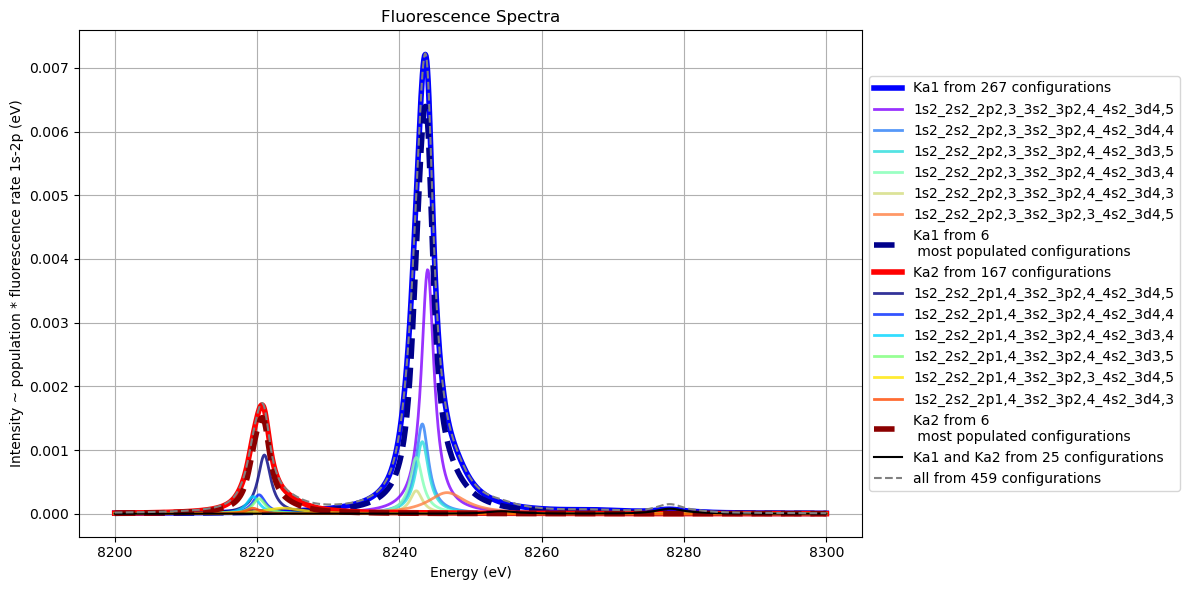

In [ ]:
cmap1 = plt.get_cmap('rainbow')
cmap2 = plt.get_cmap('jet')

plt.figure(figsize=(16, 6))

    
plt.plot(energy_range, Ka1_accumulated_spectrum, 
         label=f'Ka1 from {n_ka1} configurations',
         color='Blue', linestyle='-', linewidth = 4)

num_selected_Ka1 = len(visited_Ka1_configurations_thresholded)
Ka1_accumulated_selected_spectrum = np.zeros_like(energy_range)
f_line_Ka1_selected = {}
for idx, (conf, population) in enumerate(zip(visited_Ka1_configurations_thresholded, integral_values_Ka1_sorted_thresholded)):
    color = cmap1(idx / num_selected_Ka1)
    f_line_dict = f_line_dict_relativistic[conf][0]
    f_line_Ka1_selected[conf] = f_line_dict
    spectrum_conf = spectrum_lorentzian_Ka1(f_line_dict, population)
    Ka1_accumulated_selected_spectrum += spectrum_conf
    plt.plot(energy_range, spectrum_conf, color=color, linewidth = 2, alpha = 0.8, 
             label=f'{conf}')    
pd.set_option('display.max_columns', None)  # Show all columns without wrapping
pd.set_option('display.width', 1000)  # Adjust the width to avoid line breaks
df = pd.DataFrame(f_line_Ka1_selected).T
print(df)
print('\n')

plt.plot(energy_range, Ka1_accumulated_selected_spectrum, 
         label=f'Ka1 from {num_selected_Ka1}\n most populated configurations',
         color='DarkBlue', linestyle='--', linewidth = 4)



plt.plot(energy_range, Ka2_accumulated_spectrum, 
         label=f'Ka2 from {n_ka2} configurations',
         color='Red', linestyle='-', linewidth = 4)

num_selected_Ka2 = len(visited_Ka2_configurations_thresholded)
Ka2_accumulated_selected_spectrum = np.zeros_like(energy_range)
f_line_Ka2_selected = {}
for idx, (conf, population) in enumerate(zip(visited_Ka2_configurations_thresholded, integral_values_Ka2_sorted_thresholded)):
    color = cmap2(idx / num_selected_Ka2)
    f_line_dict = f_line_dict_relativistic[conf][0]
    f_line_Ka2_selected[conf] = f_line_dict
    spectrum_conf = spectrum_lorentzian_Ka2(f_line_dict, population)
    Ka2_accumulated_selected_spectrum += spectrum_conf
    plt.plot(energy_range, spectrum_conf, color=color, linewidth = 2, alpha = 0.8, 
             label=f'{conf}')
pd.set_option('display.max_columns', None)  # Show all columns without wrapping
pd.set_option('display.width', 1000)  # Adjust the width to avoid line breaks
df = pd.DataFrame(f_line_Ka2_selected).T
print(df)

plt.plot(energy_range, Ka2_accumulated_selected_spectrum, 
         label=f'Ka2 from {num_selected_Ka1}\n most populated configurations',
         color='DarkRed', linestyle='--', linewidth = 4)




plt.plot(energy_range, Ka1_and_Ka2__accumulated_spectrum, 
         label=f'Ka1 and Ka2 from {n_ka1_and_2} configurations',
         color='Black', linestyle='-')

plt.plot(energy_range, Ka1_accumulated_spectrum + Ka2_accumulated_spectrum + Ka1_and_Ka2__accumulated_spectrum, 
         label=f'all from {len(visited_2p_hole_configurations)} configurations',
         color='Gray', linestyle='--')

plt.xlabel('Energy (eV)')
plt.ylabel('Intensity ~ population * fluorescence rate 1s-2p (eV)')
plt.title('Fluorescence Spectra')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout(rect=[0, 0, 0.75, 1])
plt.grid(True)
plt.show()

### most probable pathways and effective enhacement for Ka1

#### find probable pathways with processes and estimated transition times

In [ ]:
def find_probable_pathways_with_processes_and_times(config_initial, configs_of_interest, transition_matrices, ar_all_configurations, threshold, max_path_length):
    """
    Find the most probable pathways from the initial state to the states of interest, including the process types and transition times.

    Parameters:
    config_initial (str): The initial configuration.
    configs_of_interest (list of str): Configurations of interest.
    transition_matrices (dict of np.ndarray): The transition rate matrices for each process type.
    ar_all_configurations (list of str): List of all configurations.
    threshold (float): The probability threshold for considering a pathway.
    max_path_length (int): The maximum length of the pathways to consider.

    Returns:
    dict: A dictionary containing the most probable pathways for each configuration of interest, including process types and transition times.
    set: A set of intermediate states encountered in the pathways.
    """
    def find_paths(current_index, current_branching_ratio, current_path, current_processes, current_times, current_branching_ratios, length):
        if length > max_path_length or current_branching_ratio < threshold:
            return
        current_path.append(current_index)
        if current_index in indices_of_interest:
            pathways[current_index].append((current_branching_ratio, list(current_path), list(current_processes), list(current_times), list(current_branching_ratios)))
        for next_index in range(len(R_ij)):
            if R_ij[next_index, current_index] > 0:
                # Determine the process type with the maximum contribution
                max_process = max(transition_matrices.keys(), key=lambda x: transition_matrices[x][next_index, current_index])
                max_value = transition_matrices[max_process][next_index, current_index]
                total_rate = -R_ij[current_index, current_index]
                branching_ratio = max_value / total_rate
                current_processes.append(max_process)
                current_times.append(1 / max_value)
                current_branching_ratios.append(branching_ratio)
                find_paths(next_index, current_branching_ratio * branching_ratio, list(current_path), list(current_processes), list(current_times), list(current_branching_ratios), length + 1)
                current_processes.pop()
                current_times.pop()
                current_branching_ratios.pop()

    # Find the index of the initial configuration
    i0 = ar_all_configurations.index(config_initial)
    # Find indices of configurations of interest
    indices_of_interest = [ar_all_configurations.index(conf) for conf in configs_of_interest]
    
    pathways = defaultdict(list)
    R_ij = sum(transition_matrices.values())
    find_paths(i0, 1.0, [], [], [], [], 0)
    
    # Filter pathways
    filtered_pathways = {}
    all_intermediate_states = set()
    for index in indices_of_interest:
        if index in pathways:
            pathways[index].sort(reverse=True, key=lambda x: x[0])
            max_branching_ratio = pathways[index][0][0] if pathways[index] else 0
            filtered_pathways[index] = [(br, path, processes, times, branching_ratios) for br, path, processes, times, branching_ratios in pathways[index] if br >= 0.1 * max_branching_ratio]
            for _, path, _, _, _ in filtered_pathways[index]:
                all_intermediate_states.update(path)
    
    # Convert indices to configuration strings for output
    filtered_pathways_str = {
        ar_all_configurations[index]: [
            (br, [ar_all_configurations[i] for i in path], processes, times, branching_ratios) for br, path, processes, times, branching_ratios in pathways
        ]
        for index, pathways in filtered_pathways.items()
    }
    all_intermediate_states_str = {ar_all_configurations[state] for state in all_intermediate_states}
    
    return filtered_pathways_str, all_intermediate_states_str

In [ ]:
configurations_of_interest = visited_Ka1_configurations_thresholded
threshold = 1e-4
max_path_length = 5

# Find the pathways
pathways_str, intermediate_states_str = find_probable_pathways_with_processes_and_times(
    initial_configuration, configurations_of_interest, {'A': rate_A_fsm1_ij, 'F': rate_F_fsm1_ij, 'P': J_pump_t_max * rate_PV_nm2_ij}, 
    visited_configurations, threshold, max_path_length)

for config_str in configurations_of_interest:
    print(f"\nPathways to {config_str}:\n")
    if config_str in pathways_str:
        for br, path, processes, times, branching_ratios in pathways_str[config_str]:
            for i, config in enumerate(path):
                if i > 0:
                    print(f"    | {processes[i-1]}, {times[i-1]:.2f} fs, br={branching_ratios[i-1]:.2f}")
                print(f"  {config}")
            print(f"pathway branching ratio = {br:.4f}\n")
    else:
        print("No pathways found.")
    print()

print("Intermediate states encountered:")
for state in intermediate_states_str:
    print(state)


Pathways to 1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,5:

  1s2_2s2_2p2,4_3s2_3p2,4_4s2_3d4,5
    | P, 64.63 fs, br=0.26
  1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,5
pathway branching ratio = 0.2614



Pathways to 1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,4:

  1s2_2s2_2p2,4_3s2_3p2,4_4s2_3d4,5
    | P, 35.11 fs, br=0.48
  1s2_2s1_2p2,4_3s2_3p2,4_4s2_3d4,5
    | A, 0.42 fs, br=0.19
  1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,4
pathway branching ratio = 0.0927



Pathways to 1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d3,5:

  1s2_2s2_2p2,4_3s2_3p2,4_4s2_3d4,5
    | P, 35.11 fs, br=0.48
  1s2_2s1_2p2,4_3s2_3p2,4_4s2_3d4,5
    | A, 0.50 fs, br=0.16
  1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d3,5
pathway branching ratio = 0.0773



Pathways to 1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d3,4:

  1s2_2s2_2p2,4_3s2_3p2,4_4s2_3d4,5
    | P, 35.11 fs, br=0.48
  1s2_2s1_2p2,4_3s2_3p2,4_4s2_3d4,5
    | A, 0.45 fs, br=0.18
  1s2_2s2_2p2,3_3s2_3p2,3_4s2_3d4,5
    | A, 0.64 fs, br=0.38
  1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d3,4
pathway branching ratio = 0.0329

  1s2_2s2_2p2,4_3s2_3

#### effective rate and effective enhancement

In [ ]:
def is_valid_pathway(processes):
    # Check if the pathway matches the pattern 'P', 'PA', 'PAA', 'PAAA', etc.
    p_count = processes.count('P')
    if p_count != 1:
        return False  # Only one 'P' is allowed
    p_index = processes.index('P')
    for process in processes[p_index + 1:]:
        if process != 'A':
            return False
    return True

def calculate_effective_photoionization_rate(pathways_str):
    effective_rates = {}

    for final_config, pathways in pathways_str.items():
        effective_rate = 0.0

        for br, path, processes, times, branching_ratios in pathways:
            if is_valid_pathway(processes):
                # Calculate the rate of the photoionization process
                P_rate = 0.0
                for i, process in enumerate(processes):
                    if process == 'P':
                        P_rate = 1 / times[i]  # P_rate is the inverse of the time
                        break

                # Calculate the weight for this pathway, excluding the P process
                weight = 1
                for j, sub_process in enumerate(processes):
                    if sub_process == 'A':
                        weight *= branching_ratios[j]

                # Add the weighted rate to the effective rate
                effective_rate += P_rate * weight

        effective_rates[final_config] = effective_rate

    return effective_rates

# Example usage
effective_rates = calculate_effective_photoionization_rate(pathways_str)

# Print the effective photoionization rates
for config, rate in effective_rates.items():
    print(f"Configuration: {config}, Effective Photoionization Rate: {rate:.4f} fs^-1")


Configuration: 1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,5, Effective Photoionization Rate: 0.0155 fs^-1
Configuration: 1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,4, Effective Photoionization Rate: 0.0055 fs^-1
Configuration: 1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d3,5, Effective Photoionization Rate: 0.0046 fs^-1
Configuration: 1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d3,4, Effective Photoionization Rate: 0.0031 fs^-1
Configuration: 1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,3, Effective Photoionization Rate: 0.0012 fs^-1
Configuration: 1s2_2s2_2p2,3_3s2_3p2,3_4s2_3d4,5, Effective Photoionization Rate: 0.0051 fs^-1


In [ ]:
i_neut = visited_configurations.index(initial_configuration)


hole2p_configuration = '1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,5'
i_gg = visited_configurations.index(hole2p_configuration)


effective_enhancement_due_PAA_cascades = (sum(effective_rates.values()) / J_pump_t_max) / rate_PV_nm2_ij[i_gg, i_neut]

print(f'effective_enhancement_due_PAA_cascades = {effective_enhancement_due_PAA_cascades:.2f}')

effective_enhancement_due_PAA_cascades = 2.26


### effective rate equation for selected configurations

In [ ]:
def rate_equation_for_populations_i_t_selected(selected_configurations, rate_AF_fsm1_ij_selected, rate_PV_nm2_ij_selected):
    # Find the indices of the selected configurations
    selected_indices = [visited_configurations.index(config) for config in selected_configurations]
    
    # Create the initial population vector for the selected configurations
    initial_population_i_selected = initial_population_i[np.ix_(selected_indices)] 

    # Define the rate equation for the subsystem
    def rate_equation_selected(t, p):
        rate_matrix_selected = rate_AF_fsm1_ij_selected + pump_fluence * I_pump(t) * rate_PV_nm2_ij_selected
        dpdt = rate_matrix_selected @ p
        return dpdt


    # Solve the ODE system for the selected configurations
    solution_selected = solve_ivp(rate_equation_selected, t_span, initial_population_i_selected, t_eval=t_eval, method='RK45')

    # Extract the solution for the selected configurations
    xatom_t_selected = np.asarray(solution_selected.t)
    xatom_populations_i_t_selected = np.asarray(solution_selected.y)
    
    return xatom_t_selected, xatom_populations_i_t_selected

#### states from cascade

In [ ]:
# Selected subset of configurations
selected_configurations_Ka1_PAA = list(intermediate_states_str)
print('selected_configurations_Ka1_PAA = ')
for conf in selected_configurations_Ka1_PAA:
    print(conf)

# Find the indices of the selected configurations
selected_indices_Ka1_PAA = [visited_configurations.index(config) for config in selected_configurations_Ka1_PAA]

# Extract the submatrix for the selected configurations from the full rate matrices
rate_AF_fsm1_ij_selected_Ka1_PAA = rate_AF_fsm1_ij[np.ix_(selected_indices_Ka1_PAA, selected_indices_Ka1_PAA)]
rate_PV_nm2_ij_selected_Ka1_PAA = rate_PV_nm2_ij[np.ix_(selected_indices_Ka1_PAA, selected_indices_Ka1_PAA)]

xatom_t_selected_Ka1_PAA, xatom_populations_i_t_selected_Ka1_PAA = rate_equation_for_populations_i_t_selected(
    selected_configurations_Ka1_PAA, rate_AF_fsm1_ij_selected_Ka1_PAA, rate_PV_nm2_ij_selected_Ka1_PAA)

selected_configurations_Ka1_PAA = 
1s2_2s2_2p1,4_3s2_3p2,4_4s2_3d4,5
1s2_2s1_2p2,4_3s2_3p2,4_4s2_3d4,5
1s2_2s2_2p2,4_3s2_3p2,4_4s2_3d3,4
1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d3,4
1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d3,5
1s2_2s2_2p2,3_3s2_3p1,4_4s2_3d4,5
1s2_2s2_2p2,4_3s2_3p2,4_4s2_3d4,5
1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,5
1s2_2s2_2p2,3_3s2_3p2,3_4s2_3d4,5
1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,4
1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,3
1s2_2s2_2p2,4_3s2_3p2,3_4s2_3d4,5
1s2_2s2_2p2,4_3s2_3p2,4_4s2_3d4,3


#### effective two states

In [ ]:
i_neut = visited_configurations.index(initial_configuration)

hole2p_configuration = '1s2_2s2_2p2,3_3s2_3p2,4_4s2_3d4,5'
i_gg = visited_configurations.index(hole2p_configuration)

# Selected subset of configurations
selected_configurations_Ka1_eff_two = [initial_configuration, hole2p_configuration]

# Find the indices of the selected configurations
selected_indices_Ka1_eff_two = [i_neut, i_gg]

# Extract the submatrix for the selected configurations from the full rate matrices
rate_AF_fsm1_ij_selected_Ka1_eff_two = rate_AF_fsm1_ij[np.ix_(selected_indices_Ka1_eff_two, selected_indices_Ka1_eff_two)]

rate_PV_nm2_ij_effective_Ka1_eff_two = rate_PV_nm2_ij
rate_PV_nm2_ij_effective_Ka1_eff_two[i_gg, i_neut] *= effective_enhancement_due_PAA_cascades
rate_PV_nm2_ij_selected_effective_Ka1_eff_two = rate_PV_nm2_ij_effective_Ka1_eff_two[np.ix_(selected_indices_Ka1_eff_two, selected_indices_Ka1_eff_two)]

xatom_t_selected_effective_Ka1_eff_two, xatom_populations_i_t_selected_effective_Ka1_eff_two = rate_equation_for_populations_i_t_selected(
    selected_configurations_Ka1_eff_two, rate_AF_fsm1_ij_selected_Ka1_eff_two, rate_PV_nm2_ij_selected_effective_Ka1_eff_two)

#### plotting

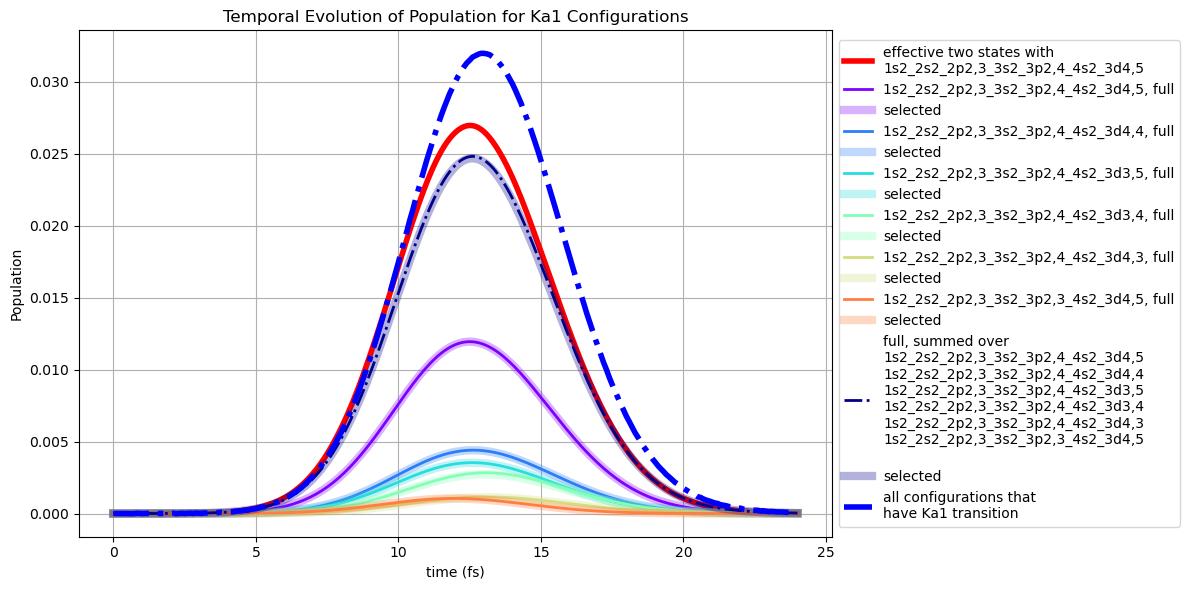

In [ ]:
cmap = plt.get_cmap('rainbow')

plt.figure(figsize=(16, 6))

for conf, population in zip(selected_configurations_Ka1_eff_two, xatom_populations_i_t_selected_effective_Ka1_eff_two):
    if sum(extract_2p_electrons(conf)) < 6:
        plt.plot(xatom_t_selected_effective_Ka1_eff_two, population, 
                 label=f'effective two states with \n{conf}', 
                 color = 'Red', linewidth = 4)
        
num_selected = len(visited_Ka1_configurations_thresholded)

populations_total_Ka1_thresholded_full = np.zeros_like(xatom_relativistic_t)
populations_total_Ka1_thresholded_sel = np.zeros_like(xatom_t_selected_Ka1_PAA)

conf_for_label = 'full, summed over\n' 

for idx, conf in enumerate(visited_Ka1_configurations_thresholded):
    color = cmap(idx / num_selected)
    
    conf_for_label = conf_for_label + f'{conf}\n'
    
    iconf = visited_configurations.index(conf)
    populations_iconf = xatom_relativistic_populations_i_t[iconf, :]
    populations_total_Ka1_thresholded_full += populations_iconf   
    plt.plot(xatom_relativistic_t, populations_iconf, 
             color=color, linewidth = 2, label=f'{conf}, full')
    
    iconf = selected_configurations_Ka1_PAA.index(conf)
    populations_iconf = xatom_populations_i_t_selected_Ka1_PAA[iconf, :]
    populations_total_Ka1_thresholded_sel += populations_iconf
    plt.plot(xatom_t_selected_Ka1_PAA, populations_iconf, 
             color=color, linewidth = 6, alpha = 0.3, label=f'selected')
    
    
plt.plot(xatom_relativistic_t, populations_total_Ka1_thresholded_full, 
         '-.', color='Darkblue', linewidth = 2, label=conf_for_label)

plt.plot(xatom_t_selected_Ka1_PAA, populations_total_Ka1_thresholded_sel, 
         '-', color='Darkblue', linewidth = 6, alpha = 0.3, label='selected')
        
populations_total_Ka1_full = np.zeros_like(xatom_relativistic_t)

for conf in visited_Ka1_configurations:  
    iconf = visited_configurations.index(conf)
    populations_iconf = xatom_relativistic_populations_i_t[iconf, :]
    populations_total_Ka1_full += populations_iconf   

plt.plot(xatom_relativistic_t, populations_total_Ka1_full, 
         '-.', color='Blue', linewidth = 4, label='all configurations that \nhave Ka1 transition')

plt.xlabel('time (fs)')
plt.ylabel('Population')
plt.title('Temporal Evolution of Population for Ka1 Configurations')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.75, 1])  # Adjust the plot area to make space for the legend
plt.show()